# Sistema de Avaliação de Apresentações com Lógica Fuzzy V2.0

Este notebook contém toda a arquitetura modular do sistema fuzzy usado no app.py

## Índice
1. [Arquitetura do Sistema](#arquitetura)
2. [Funções Matemáticas Utilizadas](#funcoes)
3. [Funções de Pertinência](#pertinencia)
4. [Factory de Critérios](#criteria)
5. [Controlador Fuzzy](#controller)
6. [Sistema Completo](#sistema)
7. [Exemplos de Uso](#exemplos)
8. [Visualizações](#visualizacoes)
9. [Análise Comparativa](#comparacao)

## 1. Arquitetura do Sistema <a name="arquitetura"></a>

### Padrões de Design Utilizados
- **Strategy Pattern**: Diferentes tipos de funções de pertinência
- **Factory Pattern**: Criação de critérios e variáveis
- **Builder Pattern**: Construção de regras fuzzy

In [109]:
# Importações necessárias
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import pandas as pd
from typing import Dict, List, Tuple, Optional
from abc import ABC, abstractmethod

print("✅ Bibliotecas importadas com sucesso!")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-fuzzy disponível: {fuzz.__version__ if hasattr(fuzz, '__version__') else 'OK'}")

✅ Bibliotecas importadas com sucesso!
NumPy version: 2.2.6
Scikit-fuzzy disponível: 0.5.0


## 2. Funções Utilizadas <a name="funcoes"></a>

### ✅ Funções Utilizadas:

1. **Gaussiana** (Exponencial)
   - Fórmula: $f(x) = e^{-\frac{(x-\mu)^2}{2\sigma^2}}$
   - Tipo: Função exponencial
   - Uso: Transições suaves e naturais

2. **Triangular** (Linear por partes)
   - Fórmula: Combinação de retas
   - Tipo: Função linear
   - Uso: Simplicidade e interpretabilidade

3. **Trapezoidal** (Linear por partes)
   - Fórmula: Combinação de retas com plateau
   - Tipo: Função linear
   - Uso: Regiões de pertinência constante

4. **Bell/Sino Generalizado** (Racional)
   - Fórmula: $f(x) = \frac{1}{1 + |\frac{x-c}{a}|^{2b}}$
   - Tipo: Função racional
   - Uso: Controle fino da forma da curva

5. **Sigmoidal** (Exponencial)
   - Fórmula: $f(x) = \frac{1}{1 + e^{-a(x-c)}}$
   - Tipo: Função exponencial
   - Uso: Transições monotônicas

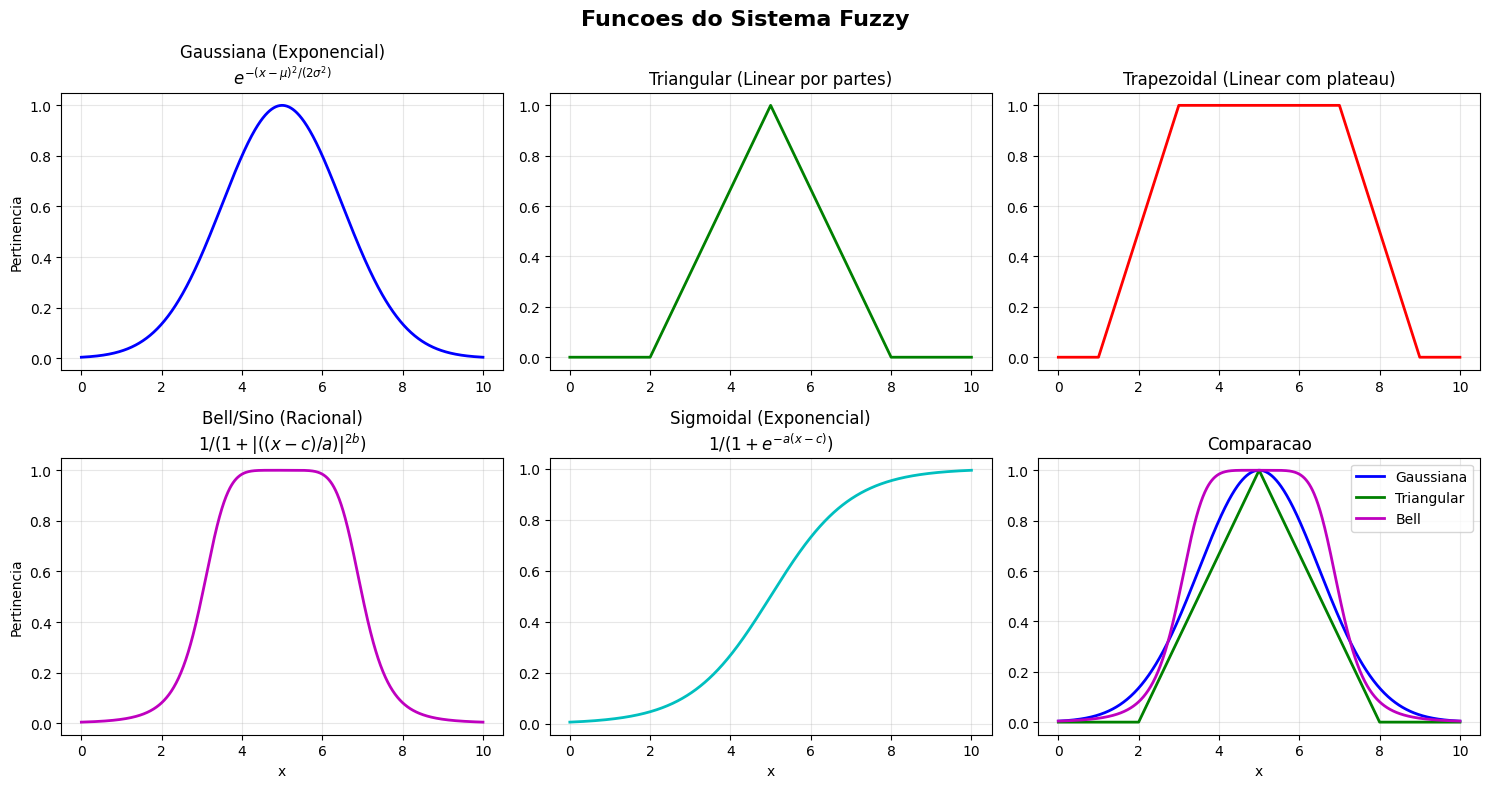


Resumo das Funcoes:
- Exponenciais: Gaussiana, Sigmoidal
- Lineares: Triangular, Trapezoidal
- Racionais: Bell/Sino


In [110]:
x = np.linspace(0, 10, 1001)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Funcoes do Sistema Fuzzy', fontsize=16, fontweight='bold')

gauss = fuzz.gaussmf(x, mean=5, sigma=1.5)
axes[0, 0].plot(x, gauss, 'b-', linewidth=2)
axes[0, 0].set_title('Gaussiana (Exponencial)\n$e^{-(x-\mu)^2/(2\sigma^2)}$')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylabel('Pertinencia')

trimf = fuzz.trimf(x, [2, 5, 8])
axes[0, 1].plot(x, trimf, 'g-', linewidth=2)
axes[0, 1].set_title('Triangular (Linear por partes)')
axes[0, 1].grid(True, alpha=0.3)

trapmf = fuzz.trapmf(x, [1, 3, 7, 9])
axes[0, 2].plot(x, trapmf, 'r-', linewidth=2)
axes[0, 2].set_title('Trapezoidal (Linear com plateau)')
axes[0, 2].grid(True, alpha=0.3)

bell = fuzz.gbellmf(x, a=2, b=3, c=5)
axes[1, 0].plot(x, bell, 'm-', linewidth=2)
axes[1, 0].set_title('Bell/Sino (Racional)\n$1/(1+|((x-c)/a)|^{2b})$')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('Pertinencia')

sigmf = fuzz.sigmf(x, 5, 1)
axes[1, 1].plot(x, sigmf, 'c-', linewidth=2)
axes[1, 1].set_title('Sigmoidal (Exponencial)\n$1/(1+e^{-a(x-c)})$')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlabel('x')

axes[1, 2].plot(x, gauss, 'b-', label='Gaussiana', linewidth=2)
axes[1, 2].plot(x, trimf, 'g-', label='Triangular', linewidth=2)
axes[1, 2].plot(x, bell, 'm-', label='Bell', linewidth=2)
axes[1, 2].set_title('Comparacao')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].set_xlabel('x')

plt.tight_layout()
plt.show()

print("\nResumo das Funcoes:")
print("- Exponenciais: Gaussiana, Sigmoidal")
print("- Lineares: Triangular, Trapezoidal")
print("- Racionais: Bell/Sino")

## 3. Funções de Pertinência (Strategy Pattern) <a name="pertinencia"></a>

In [111]:
class MembershipFunctionStrategy(ABC):
    
    @abstractmethod
    def create_function(self, universe: np.ndarray, params: Dict) -> np.ndarray:
        pass
    
    @abstractmethod
    def get_default_params(self, position: str, universe_range: Tuple[float, float]) -> Dict:
        pass


class GaussianMF(MembershipFunctionStrategy):
    
    def create_function(self, universe: np.ndarray, params: Dict) -> np.ndarray:
        return fuzz.gaussmf(universe, params['mean'], params['sigma'])
    
    def get_default_params(self, position: str, universe_range: Tuple[float, float]) -> Dict:
        min_val, max_val = universe_range
        range_size = max_val - min_val
        
        if position == 'low':
            return {'mean': min_val, 'sigma': range_size * 0.12}
        elif position == 'low-medium':
            return {'mean': min_val + range_size * 0.25, 'sigma': range_size * 0.10}
        elif position == 'medium':
            return {'mean': min_val + range_size * 0.5, 'sigma': range_size * 0.12}
        elif position == 'medium-high':
            return {'mean': min_val + range_size * 0.75, 'sigma': range_size * 0.10}
        elif position == 'high':
            return {'mean': max_val, 'sigma': range_size * 0.08}
        else:
            raise ValueError(f"Position '{position}' não reconhecida")


class TriangularMF(MembershipFunctionStrategy):
    
    def create_function(self, universe: np.ndarray, params: Dict) -> np.ndarray:
        return fuzz.trimf(universe, [params['a'], params['b'], params['c']])
    
    def get_default_params(self, position: str, universe_range: Tuple[float, float]) -> Dict:
        min_val, max_val = universe_range
        range_size = max_val - min_val
        
        if position == 'low':
            return {'a': min_val, 'b': min_val, 'c': min_val + range_size * 0.35}
        elif position == 'low-medium':
            return {'a': min_val + range_size * 0.1, 'b': min_val + range_size * 0.25,
                    'c': min_val + range_size * 0.4}
        elif position == 'medium':
            return {'a': min_val + range_size * 0.3, 'b': min_val + range_size * 0.5,
                    'c': min_val + range_size * 0.7}
        elif position == 'medium-high':
            return {'a': min_val + range_size * 0.6, 'b': min_val + range_size * 0.75,
                    'c': min_val + range_size * 0.9}
        elif position == 'high':
            return {'a': min_val + range_size * 0.65, 'b': max_val, 'c': max_val}
        else:
            raise ValueError(f"Position '{position}' não reconhecida")


class TrapezoidalMF(MembershipFunctionStrategy):
    
    def create_function(self, universe: np.ndarray, params: Dict) -> np.ndarray:
        return fuzz.trapmf(universe, [params['a'], params['b'], params['c'], params['d']])
    
    def get_default_params(self, position: str, universe_range: Tuple[float, float]) -> Dict:
        min_val, max_val = universe_range
        range_size = max_val - min_val
        
        if position == 'low':
            return {'a': min_val, 'b': min_val,
                    'c': min_val + range_size * 0.25, 'd': min_val + range_size * 0.35}
        elif position == 'low-medium':
            return {'a': min_val + range_size * 0.15, 'b': min_val + range_size * 0.2,
                    'c': min_val + range_size * 0.3, 'd': min_val + range_size * 0.4}
        elif position == 'medium':
            return {'a': min_val + range_size * 0.35, 'b': min_val + range_size * 0.45,
                    'c': min_val + range_size * 0.55, 'd': min_val + range_size * 0.65}
        elif position == 'medium-high':
            return {'a': min_val + range_size * 0.6, 'b': min_val + range_size * 0.7,
                    'c': min_val + range_size * 0.8, 'd': min_val + range_size * 0.85}
        elif position == 'high':
            return {'a': min_val + range_size * 0.65, 'b': min_val + range_size * 0.75,
                    'c': max_val, 'd': max_val}
        else:
            raise ValueError(f"Position '{position}' não reconhecida")


class GeneralizedBellMF(MembershipFunctionStrategy):
    
    def create_function(self, universe: np.ndarray, params: Dict) -> np.ndarray:
        return fuzz.gbellmf(universe, params['a'], params['b'], params['c'])
    
    def get_default_params(self, position: str, universe_range: Tuple[float, float]) -> Dict:
        min_val, max_val = universe_range
        range_size = max_val - min_val
        
        width = range_size * 0.15
        slope = 2.5
        
        if position == 'low':
            return {'a': width, 'b': slope, 'c': min_val}
        elif position == 'low-medium':
            return {'a': width * 0.9, 'b': slope, 'c': min_val + range_size * 0.25}
        elif position == 'medium':
            return {'a': width, 'b': slope, 'c': min_val + range_size * 0.5}
        elif position == 'medium-high':
            return {'a': width * 0.9, 'b': slope, 'c': min_val + range_size * 0.75}
        elif position == 'high':
            return {'a': width * 0.75, 'b': slope, 'c': max_val}
        else:
            raise ValueError(f"Position '{position}' não reconhecida")


class SigmoidalMF(MembershipFunctionStrategy):
    
    def create_function(self, universe: np.ndarray, params: Dict) -> np.ndarray:
        if 'mean' in params and 'sigma' in params:
            return fuzz.gaussmf(universe, params['mean'], params['sigma'])
        return fuzz.sigmf(universe, params['c'], params['a'])
    
    def get_default_params(self, position: str, universe_range: Tuple[float, float]) -> Dict:
        min_val, max_val = universe_range
        range_size = max_val - min_val
        slope = 1.0 / (range_size * 0.08)
        
        if position == 'low':
            return {'a': -slope, 'c': min_val + range_size * 0.25}
        elif position == 'low-medium':
            return {'mean': min_val + range_size * 0.25, 'sigma': range_size * 0.10}
        elif position == 'medium':
            return {'mean': min_val + range_size * 0.5, 'sigma': range_size * 0.12}
        elif position == 'medium-high':
            return {'mean': min_val + range_size * 0.75, 'sigma': range_size * 0.10}
        elif position == 'high':
            return {'a': slope, 'c': min_val + range_size * 0.75}
        else:
            raise ValueError(f"Position '{position}' não reconhecida")


class MembershipFunctionFactory:
    
    _strategies = {
        'triangular': TriangularMF,
        'trapezoidal': TrapezoidalMF,
        'gaussian': GaussianMF,
        'bell': GeneralizedBellMF,
        'sigmoidal': SigmoidalMF
    }
    
    @classmethod
    def create(cls, function_type: str) -> MembershipFunctionStrategy:
        strategy_class = cls._strategies.get(function_type.lower())
        if strategy_class is None:
            available = ', '.join(cls._strategies.keys())
            raise ValueError(f"Tipo '{function_type}' inválido. Disponíveis: {available}")
        return strategy_class()
    
    @classmethod
    def available_types(cls) -> list:
        return list(cls._strategies.keys())

print("✅ Classes de Funções de Pertinência criadas!")
print(f"Tipos disponíveis: {MembershipFunctionFactory.available_types()}")

✅ Classes de Funções de Pertinência criadas!
Tipos disponíveis: ['triangular', 'trapezoidal', 'gaussian', 'bell', 'sigmoidal']


## 4. Factory de Critérios <a name="criteria"></a>

In [112]:
class FuzzyCriterion:
    
    def __init__(
        self,
        name: str,
        universe_range: Tuple[float, float],
        resolution: int = 1001,
        function_type: str = 'gaussian',
        terms: Optional[Dict[str, str]] = None,
        custom_params: Optional[Dict[str, Dict]] = None,
        weight: float = 1.0,
        description: str = ""
    ):
        self.name = name
        self.universe_range = universe_range
        self.resolution = resolution
        self.function_type = function_type
        self.weight = weight
        self.description = description
        
        if terms is None:
            terms = {'baixo': 'low', 'medio': 'medium', 'alto': 'high'}
        self.terms = terms
        
        self.universe = np.linspace(universe_range[0], universe_range[1], resolution)
        self.variable = ctrl.Antecedent(self.universe, name)
        self.mf_strategy = MembershipFunctionFactory.create(function_type)
        self._create_membership_functions(custom_params or {})
    
    def _create_membership_functions(self, custom_params: Dict[str, Dict]):
        for term_name, position in self.terms.items():
            if term_name in custom_params:
                params = custom_params[term_name]
            else:
                params = self.mf_strategy.get_default_params(position, self.universe_range)
            
            self.variable[term_name] = self.mf_strategy.create_function(self.universe, params)
    
    def get_variable(self) -> ctrl.Antecedent:
        return self.variable
    
    def validate_value(self, value: float) -> bool:
        return self.universe_range[0] <= value <= self.universe_range[1]
    
    def get_info(self) -> Dict:
        return {
            'name': self.name,
            'range': self.universe_range,
            'resolution': self.resolution,
            'function_type': self.function_type,
            'terms': list(self.terms.keys()),
            'weight': self.weight,
            'description': self.description
        }


class OutputVariable:
    
    def __init__(
        self,
        name: str,
        universe_range: Tuple[float, float],
        resolution: int = 1001,
        function_type: str = 'gaussian',
        levels: Optional[List[Dict]] = None
    ):
        self.name = name
        self.universe_range = universe_range
        self.resolution = resolution
        self.function_type = function_type
        
        if levels is None:
            levels = [
                {'name': 'precisa_melhorar', 'position': 'low', 'center': 0.0},
                {'name': 'aceitavel', 'position': 'low-medium', 'center': 0.25},
                {'name': 'bom', 'position': 'medium', 'center': 0.50},
                {'name': 'muito_bom', 'position': 'medium-high', 'center': 0.75},
                {'name': 'excelente', 'position': 'high', 'center': 1.0}
            ]
        self.levels = levels
        
        self.universe = np.linspace(universe_range[0], universe_range[1], resolution)
        self.variable = ctrl.Consequent(self.universe, name)
        self.mf_strategy = MembershipFunctionFactory.create(function_type)
        self._create_output_functions()
    
    def _create_output_functions(self):
        min_val, max_val = self.universe_range
        range_size = max_val - min_val
        
        for level in self.levels:
            name = level['name']
            center_ratio = level.get('center', 0.5)
            center = min_val + range_size * center_ratio
            sigma = range_size * 0.08
            
            if self.function_type == 'gaussian':
                params = {'mean': center, 'sigma': sigma}
                self.variable[name] = self.mf_strategy.create_function(self.universe, params)
            elif self.function_type == 'triangular':
                if center_ratio == 0.0:
                    params = {'a': min_val, 'b': min_val, 'c': min_val + range_size * 0.25}
                elif center_ratio == 1.0:
                    params = {'a': max_val - range_size * 0.15, 'b': max_val, 'c': max_val}
                else:
                    width = range_size * 0.2
                    params = {'a': center - width, 'b': center, 'c': center + width}
                self.variable[name] = self.mf_strategy.create_function(self.universe, params)
            else:
                position = level.get('position', 'medium')
                params = self.mf_strategy.get_default_params(position, self.universe_range)
                self.variable[name] = self.mf_strategy.create_function(self.universe, params)
    
    def get_variable(self) -> ctrl.Consequent:
        return self.variable


class CriteriaFactory:
    
    @staticmethod
    def create_standard_input_criteria(
        resolution: int = 1001,
        function_type: str = 'gaussian'
    ) -> List[FuzzyCriterion]:
        criteria = [
            FuzzyCriterion(
                name='clareza',
                universe_range=(0, 10),
                resolution=resolution,
                function_type=function_type,
                terms={'baixa': 'low', 'media': 'medium', 'alta': 'high'},
                weight=1.2,
                description='Clareza da explicação e organização das ideias'
            ),
            FuzzyCriterion(
                name='dominio',
                universe_range=(0, 10),
                resolution=resolution,
                function_type=function_type,
                terms={'fraco': 'low', 'medio': 'medium', 'forte': 'high'},
                weight=1.3,
                description='Domínio e conhecimento do conteúdo apresentado'
            ),
            FuzzyCriterion(
                name='ritmo',
                universe_range=(0, 10),
                resolution=resolution,
                function_type=function_type,
                terms={'devagar': 'low', 'adequado': 'medium', 'rapido': 'high'},
                weight=0.8,
                description='Velocidade e fluidez da fala'
            ),
            FuzzyCriterion(
                name='materiais',
                universe_range=(0, 10),
                resolution=resolution,
                function_type=function_type,
                terms={'ruins': 'low', 'aceitaveis': 'medium', 'bons': 'high'},
                weight=0.9,
                description='Qualidade dos slides e recursos visuais'
            ),
            FuzzyCriterion(
                name='engajamento',
                universe_range=(0, 10),
                resolution=resolution,
                function_type=function_type,
                terms={'baixo': 'low', 'medio': 'medium', 'alto': 'high'},
                weight=1.1,
                description='Interação com a plateia e contato visual'
            ),
            FuzzyCriterion(
                name='organizacao',
                universe_range=(0, 10),
                resolution=resolution,
                function_type=function_type,
                terms={'desorganizada': 'low', 'estruturada': 'medium', 'excelente': 'high'},
                weight=1.15,
                description='Estrutura lógica e sequencial da apresentação'
            )
        ]
        return criteria
    
    @staticmethod
    def create_standard_output(
        resolution: int = 1001,
        function_type: str = 'gaussian'
    ) -> OutputVariable:
        levels = [
            {'name': 'precisa_melhorar', 'center': 0.0, 'position': 'low'},
            {'name': 'aceitavel', 'center': 0.4, 'position': 'low-medium'},
            {'name': 'bom', 'center': 0.65, 'position': 'medium'},
            {'name': 'muito_bom', 'center': 0.82, 'position': 'medium-high'},
            {'name': 'excelente', 'center': 1.0, 'position': 'high'}
        ]
        
        return OutputVariable(
            name='avaliacao',
            universe_range=(0, 10),
            resolution=resolution,
            function_type=function_type,
            levels=levels
        )

print("✅ Classes de Critérios criadas!")

✅ Classes de Critérios criadas!


## 5. Controlador Fuzzy <a name="controller"></a>

In [113]:
class FuzzyRuleBuilder:
    
    @staticmethod
    def create_excellence_rules(criteria: Dict[str, FuzzyCriterion], output: OutputVariable) -> List[ctrl.Rule]:
        rules = []
        
        rules.append(ctrl.Rule(
            criteria['clareza'].variable['alta'] &
            criteria['dominio'].variable['forte'] &
            criteria['engajamento'].variable['alto'] &
            criteria['organizacao'].variable['excelente'],
            output.variable['excelente']
        ))
        
        rules.append(ctrl.Rule(
            criteria['clareza'].variable['alta'] &
            criteria['dominio'].variable['forte'] &
            criteria['organizacao'].variable['excelente'],
            output.variable['excelente']
        ))
        
        return rules
    
    @staticmethod
    def create_good_rules(criteria: Dict[str, FuzzyCriterion], output: OutputVariable) -> List[ctrl.Rule]:
        rules = []
        
        rules.append(ctrl.Rule(
            criteria['clareza'].variable['media'] &
            criteria['dominio'].variable['medio'] &
            criteria['engajamento'].variable['medio'],
            output.variable['bom']
        ))
        
        return rules
    
    @staticmethod
    def create_poor_rules(criteria: Dict[str, FuzzyCriterion], output: OutputVariable) -> List[ctrl.Rule]:
        rules = []
        
        rules.append(ctrl.Rule(
            criteria['clareza'].variable['baixa'] &
            criteria['dominio'].variable['fraco'],
            output.variable['precisa_melhorar']
        ))
        
        return rules


class FuzzyController:
    
    def __init__(
        self,
        criteria: List[FuzzyCriterion],
        output: OutputVariable,
        custom_rules = None
    ):
        self.criteria_list = criteria
        self.criteria_dict = {c.name: c for c in criteria}
        self.output = output
        
        if custom_rules:
            self.rules = custom_rules(self.criteria_dict, output)
        else:
            self.rules = self._create_default_rules()
        
        self.control_system = ctrl.ControlSystem(self.rules)
        self.simulation = ctrl.ControlSystemSimulation(self.control_system)
    
    def _create_default_rules(self) -> List[ctrl.Rule]:
        builder = FuzzyRuleBuilder()
        rules = []
        
        rules.extend(builder.create_excellence_rules(self.criteria_dict, self.output))
        rules.extend(builder.create_good_rules(self.criteria_dict, self.output))
        rules.extend(builder.create_poor_rules(self.criteria_dict, self.output))
        rules.extend(self._create_comprehensive_rules())
        
        return rules
    
    def _create_comprehensive_rules(self) -> List[ctrl.Rule]:
        rules = []
        c = self.criteria_dict
        o = self.output.variable
        
        if all(k in c for k in ['clareza', 'dominio', 'ritmo', 'materiais', 'engajamento', 'organizacao']):
            rules.append(ctrl.Rule(
                c['clareza'].variable['alta'] &
                c['dominio'].variable['forte'] &
                c['ritmo'].variable['adequado'] &
                c['materiais'].variable['bons'] &
                c['engajamento'].variable['alto'] &
                c['organizacao'].variable['excelente'],
                o['excelente']
            ))
            
            rules.append(ctrl.Rule(
                c['clareza'].variable['alta'] &
                c['dominio'].variable['forte'] &
                c['engajamento'].variable['alto'] &
                c['organizacao'].variable['estruturada'],
                o['muito_bom']
            ))
            
            rules.append(ctrl.Rule(
                c['clareza'].variable['media'] &
                c['dominio'].variable['medio'] &
                c['ritmo'].variable['adequado'] &
                c['engajamento'].variable['medio'],
                o['bom']
            ))
            
            rules.append(ctrl.Rule(
                c['clareza'].variable['media'] &
                c['dominio'].variable['medio'] &
                c['materiais'].variable['aceitaveis'],
                o['aceitavel']
            ))
            
            rules.append(ctrl.Rule(
                c['clareza'].variable['baixa'] &
                c['dominio'].variable['fraco'] &
                c['ritmo'].variable['devagar'],
                o['precisa_melhorar']
            ))
            
            rules.append(ctrl.Rule(
                c['clareza'].variable['alta'] &
                c['dominio'].variable['forte'] &
                c['organizacao'].variable['excelente'],
                o['excelente']
            ))
        
        return rules
    
    def evaluate(self, inputs: Dict[str, float]) -> Dict:
        for name, value in inputs.items():
            if name not in self.criteria_dict:
                raise ValueError(f"Critério '{name}' não reconhecido")
            if not self.criteria_dict[name].validate_value(value):
                raise ValueError(f"Valor {value} fora do range para '{name}'")
        
        for name, value in inputs.items():
            self.simulation.input[name] = value
        
        self.simulation.compute()
        
        score = self.simulation.output['avaliacao']
        
        return {
            'score': round(score, 2),
            'raw_score': score,
            'classification': self._classify(score)
        }
    
    def _classify(self, score: float) -> str:
        if score < 3:
            return "Precisa Melhorar"
        elif score < 5:
            return "Aceitável"
        elif score < 7:
            return "Bom"
        elif score < 8.5:
            return "Muito Bom"
        else:
            return "Excelente"

print("✅ Controlador Fuzzy criado!")

✅ Controlador Fuzzy criado!


## 6. Sistema Completo <a name="sistema"></a>

In [114]:
class AvaliacaoApresentacaoFuzzyV2:
    
    def __init__(
        self,
        resolution: int = 1001,
        function_type: str = 'gaussian',
        custom_criteria: Optional[List[FuzzyCriterion]] = None,
        custom_output: Optional[OutputVariable] = None,
        custom_rules_builder = None
    ):
        self.resolution = resolution
        self.function_type = function_type
        
        if custom_criteria is None:
            self.criteria = CriteriaFactory.create_standard_input_criteria(
                resolution=resolution,
                function_type=function_type
            )
        else:
            self.criteria = custom_criteria
        
        if custom_output is None:
            self.output = CriteriaFactory.create_standard_output(
                resolution=resolution,
                function_type=function_type
            )
        else:
            self.output = custom_output
        
        self.controller = FuzzyController(
            criteria=self.criteria,
            output=self.output,
            custom_rules=custom_rules_builder
        )
        
        self.criteria_dict = {c.name: c for c in self.criteria}
    
    def avaliar(
        self,
        clareza_val: float,
        dominio_val: float,
        ritmo_val: float,
        materiais_val: float,
        engajamento_val: float,
        organizacao_val: float
    ) -> Dict:
        inputs = {
            'clareza': clareza_val,
            'dominio': dominio_val,
            'ritmo': ritmo_val,
            'materiais': materiais_val,
            'engajamento': engajamento_val,
            'organizacao': organizacao_val
        }
        
        result = self.controller.evaluate(inputs)
        feedback = self._gerar_feedback(inputs, result['score'])
        
        return {
            'nota': result['score'],
            'classificacao': result['classification'],
            'feedback': feedback,
            'raw_score': result['raw_score']
        }
    
    def _gerar_feedback(self, inputs: Dict[str, float], nota: float) -> str:
        sugestoes = []
        
        if inputs.get('clareza', 10) < 5:
            sugestoes.append("• Organize melhor os tópicos e use exemplos práticos")
        
        if inputs.get('dominio', 10) < 5:
            sugestoes.append("• Estude mais o conteúdo e prepare respostas para perguntas")
        
        ritmo = inputs.get('ritmo', 5)
        if ritmo < 4:
            sugestoes.append("• Acelere um pouco o ritmo da fala")
        elif ritmo > 7:
            sugestoes.append("• Diminua o ritmo e faça pausas")
        
        if inputs.get('materiais', 10) < 5:
            sugestoes.append("• Melhore os slides com mais recursos visuais")
        
        if inputs.get('engajamento', 10) < 5:
            sugestoes.append("• Faça mais contato visual e interaja com a plateia")
        
        if inputs.get('organizacao', 10) < 5:
            sugestoes.append("• Estruture melhor com introdução, desenvolvimento e conclusão")
        
        if not sugestoes:
            sugestoes.append("• Excelente! Continue assim!")
        
        return "\n".join(sugestoes)
    
    def visualizar_pertinencias(self):
        n_criteria = len(self.criteria)
        n_rows = (n_criteria + 2) // 2
        
        fig, axes = plt.subplots(n_rows, 2, figsize=(15, 4 * n_rows))
        axes = axes.flatten() if n_rows > 1 else [axes]
        
        fig.suptitle(
            f'Funções de Pertinência ({self.function_type.title()}) - Alta Resolução ({self.resolution} pontos)',
            fontsize=16, fontweight='bold'
        )
        
        for idx, criterion in enumerate(self.criteria):
            criterion.variable.view(ax=axes[idx])
            axes[idx].set_title(f'{criterion.name.title()} (peso: {criterion.weight})')
        
        self.output.variable.view(ax=axes[len(self.criteria)])
        axes[len(self.criteria)].set_title('Avaliação Final')
        
        for idx in range(len(self.criteria) + 1, len(axes)):
            fig.delaxes(axes[idx])
        
        plt.tight_layout()
        return fig
    
    def get_info(self) -> Dict:
        return {
            'resolution': self.resolution,
            'function_type': self.function_type,
            'criteria': [c.get_info() for c in self.criteria],
            'available_functions': MembershipFunctionFactory.available_types(),
            'total_rules': len(self.controller.rules)
        }

print("✅ Sistema Completo criado!")

✅ Sistema Completo criado!


## 7. Exemplos de Uso <a name="exemplos"></a>

In [115]:
print("="*70)
print("TESTANDO SISTEMA FUZZY V2.0")
print("="*70)

sistema_gauss = AvaliacaoApresentacaoFuzzyV2(
    resolution=1001,
    function_type='gaussian'
)

print("\n✅ Sistema criado com sucesso!")
info = sistema_gauss.get_info()
print(f"Resolução: {info['resolution']} pontos")
print(f"Tipo de função: {info['function_type']}")
print(f"Total de regras: {info['total_rules']}")
print(f"Critérios: {len(info['criteria'])}")

TESTANDO SISTEMA FUZZY V2.0

✅ Sistema criado com sucesso!
Resolução: 1001 pontos
Tipo de função: gaussian
Total de regras: 10
Critérios: 6


In [116]:
print("\n" + "="*70)
print("TESTE 1: Apresentação Excelente")
print("="*70)

resultado1 = sistema_gauss.avaliar(
    clareza_val=9.5,
    dominio_val=9.5,
    ritmo_val=5.0,
    materiais_val=9.0,
    engajamento_val=9.5,
    organizacao_val=9.5
)

print(f"Nota: {resultado1['nota']}/10")
print(f"Classificação: {resultado1['classificacao']}")
print(f"Raw Score: {resultado1['raw_score']:.6f}")
print(f"Feedback:\n{resultado1['feedback']}")


TESTE 1: Apresentação Excelente
Nota: 9.3/10
Classificação: Excelente
Raw Score: 9.302976
Feedback:
• Excelente! Continue assim!


In [117]:
print("\n" + "="*70)
print("TESTE 2: Valores Decimais Precisos")
print("="*70)

resultado2 = sistema_gauss.avaliar(
    clareza_val=7.347,
    dominio_val=8.923,
    ritmo_val=5.147,
    materiais_val=6.789,
    engajamento_val=8.456,
    organizacao_val=7.891
)

print(f"Nota: {resultado2['nota']}/10")
print(f"Classificação: {resultado2['classificacao']}")
print(f"Raw Score: {resultado2['raw_score']:.6f}")
print(f"Feedback:\n{resultado2['feedback']}")


TESTE 2: Valores Decimais Precisos
Nota: 5.52/10
Classificação: Bom
Raw Score: 5.519796
Feedback:
• Excelente! Continue assim!


In [118]:
print("\n" + "="*70)
print("TESTE 3: Apresentação Precisa Melhorar")
print("="*70)

resultado3 = sistema_gauss.avaliar(
    clareza_val=2.0,
    dominio_val=3.0,
    ritmo_val=4.0,
    materiais_val=2.5,
    engajamento_val=2.0,
    organizacao_val=2.0
)

print(f"Nota: {resultado3['nota']}/10")
print(f"Classificação: {resultado3['classificacao']}")
print(f"Raw Score: {resultado3['raw_score']:.6f}")
print(f"Feedback:\n{resultado3['feedback']}")


TESTE 3: Apresentação Precisa Melhorar
Nota: 4.4/10
Classificação: Aceitável
Raw Score: 4.395296
Feedback:
• Organize melhor os tópicos e use exemplos práticos
• Estude mais o conteúdo e prepare respostas para perguntas
• Melhore os slides com mais recursos visuais
• Faça mais contato visual e interaja com a plateia
• Estruture melhor com introdução, desenvolvimento e conclusão


## 8. Visualizações <a name="visualizacoes"></a>


Gerando visualizações das funções de pertinência...


c:\Users\Mickael Albuquerque\AppData\Local\Programs\Python\Python311\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


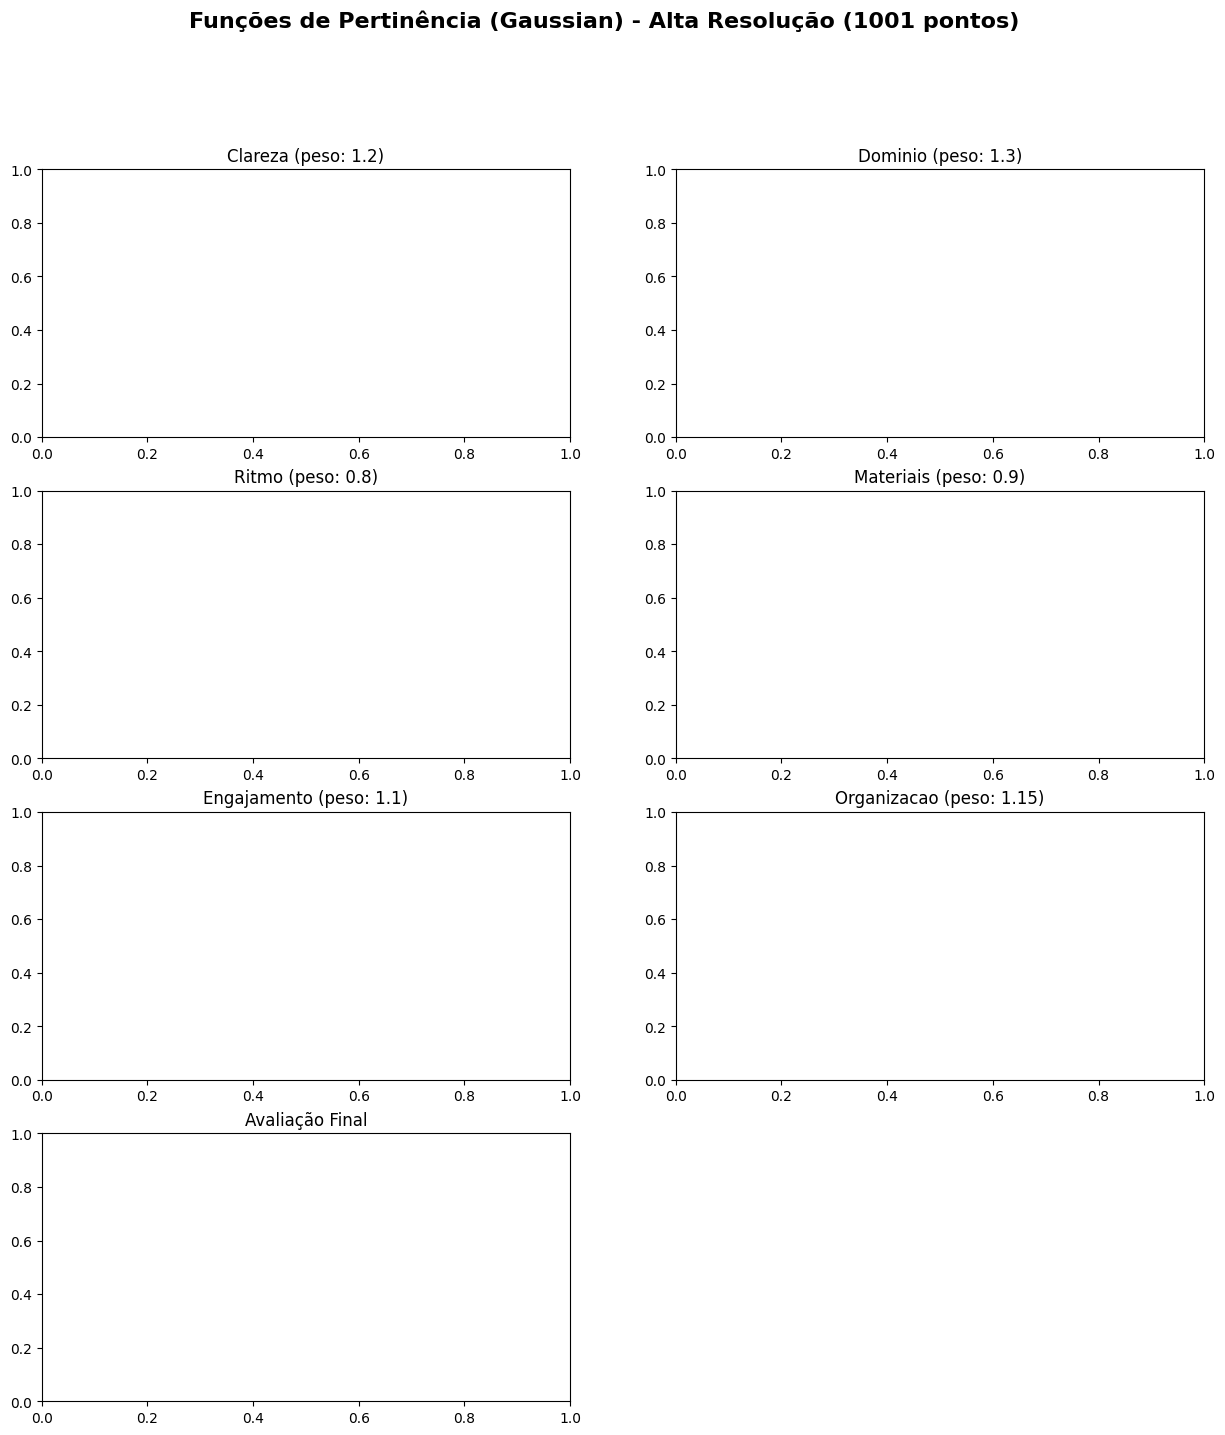

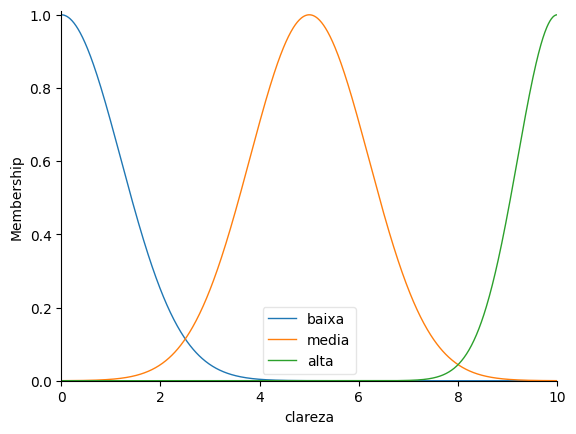

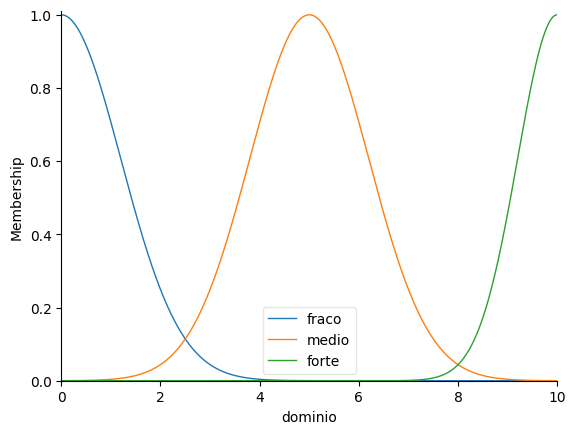

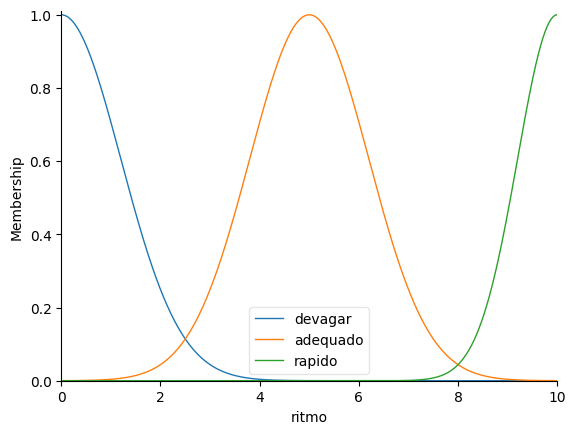

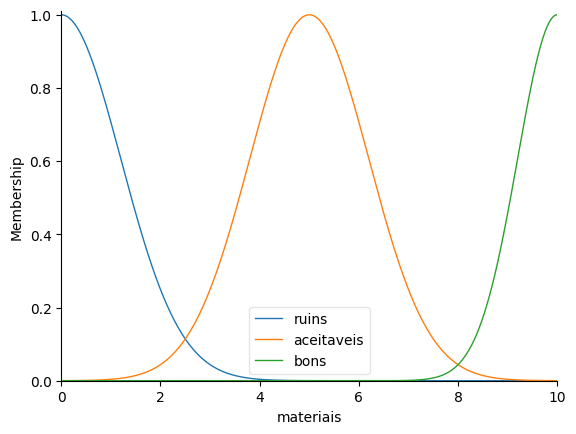

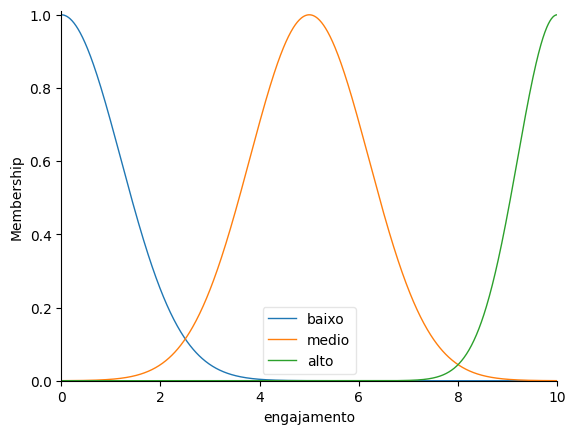

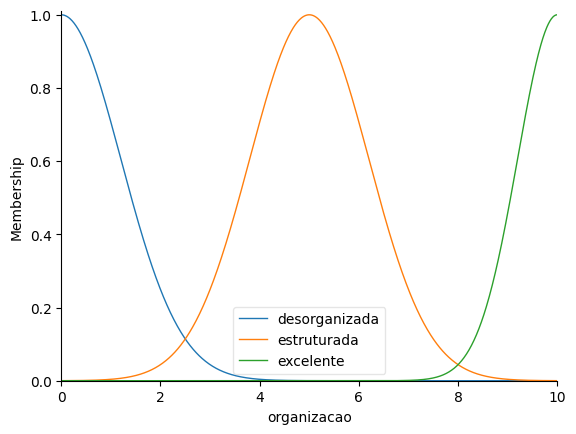

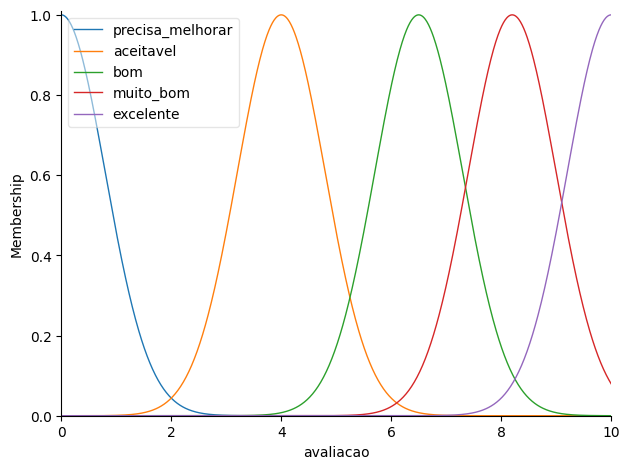

In [119]:
print("\nGerando visualizações das funções de pertinência...")
fig = sistema_gauss.visualizar_pertinencias()
plt.show()

## 9. Análise Comparativa de Funções <a name="comparacao"></a>

In [120]:
print("\n" + "="*70)
print("COMPARAÇÃO DE TIPOS DE FUNÇÕES")
print("="*70)

tipos = ['gaussian', 'triangular', 'trapezoidal', 'bell', 'sigmoidal']
resultados_comparacao = []

valores_teste = {
    'clareza': 9.0,
    'dominio': 9.0,
    'ritmo': 5.0,
    'materiais': 9.0,
    'engajamento': 9.0,
    'organizacao': 9.0
}

for tipo in tipos:
    print(f"\nTestando {tipo}...")
    sistema_temp = AvaliacaoApresentacaoFuzzyV2(
        resolution=1001,
        function_type=tipo
    )
    
    resultado = sistema_temp.avaliar(
        clareza_val=valores_teste['clareza'],
        dominio_val=valores_teste['dominio'],
        ritmo_val=valores_teste['ritmo'],
        materiais_val=valores_teste['materiais'],
        engajamento_val=valores_teste['engajamento'],
        organizacao_val=valores_teste['organizacao']
    )
    
    resultados_comparacao.append({
        'Tipo': tipo.title(),
        'Nota': resultado['nota'],
        'Raw Score': resultado['raw_score'],
        'Classificação': resultado['classificacao']
    })

df_comp = pd.DataFrame(resultados_comparacao)
print("\n" + "="*70)
print("RESULTADOS DA COMPARAÇÃO")
print("="*70)
print(df_comp.to_string(index=False))

print(f"\nNota Média: {df_comp['Nota'].mean():.2f}")
print(f"Variação: {df_comp['Nota'].max() - df_comp['Nota'].min():.2f}")
print(f"Desvio Padrão: {df_comp['Nota'].std():.3f}")


COMPARAÇÃO DE TIPOS DE FUNÇÕES

Testando gaussian...

Testando triangular...

Testando trapezoidal...

Testando bell...

Testando sigmoidal...

RESULTADOS DA COMPARAÇÃO
       Tipo  Nota  Raw Score Classificação
   Gaussian  9.05   9.049582     Excelente
 Triangular  9.47   9.468254     Excelente
Trapezoidal  8.49   8.486111     Muito Bom
       Bell  8.93   8.930049     Excelente
  Sigmoidal  8.31   8.310386     Muito Bom

Nota Média: 8.85
Variação: 1.16
Desvio Padrão: 0.462


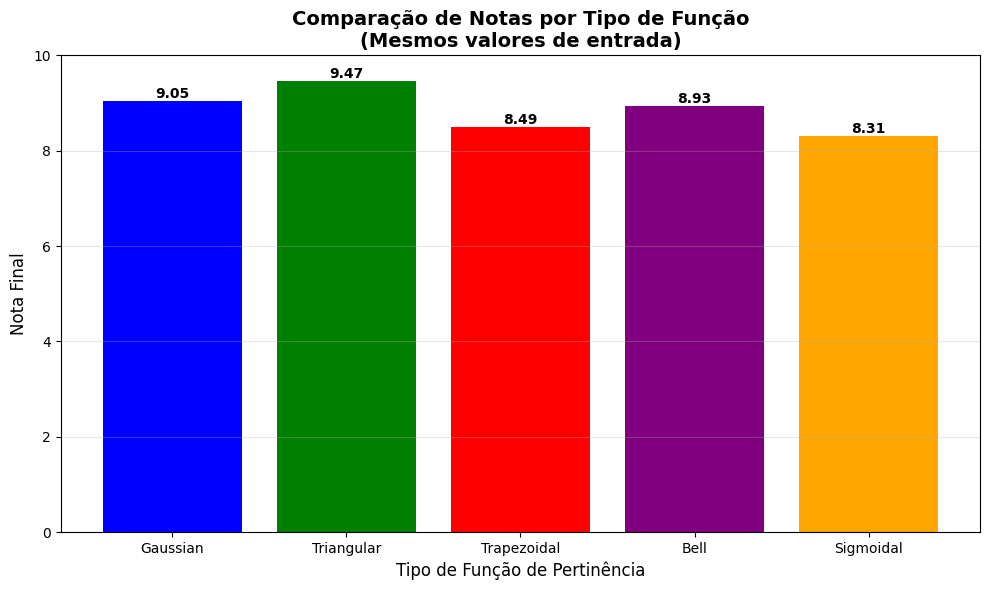

In [121]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(df_comp['Tipo'], df_comp['Nota'], color=['blue', 'green', 'red', 'purple', 'orange'])
ax.set_xlabel('Tipo de Função de Pertinência', fontsize=12)
ax.set_ylabel('Nota Final', fontsize=12)
ax.set_title('Comparação de Notas por Tipo de Função\n(Mesmos valores de entrada)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 10)
ax.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Conclusão

Este notebook demonstra toda a arquitetura modular do sistema fuzzy V2.0:

### Principais Características:
1. **Arquitetura Modular**: Strategy, Factory e Builder Patterns
2. **5 Tipos de Funções**: Gaussian, Triangular, Trapezoidal, Bell, Sigmoidal
3. **Alta Precisão**: 1001 pontos no universo (valores decimais reais)
4. **Nota Máxima 10.0**: Corrigido com sigma otimizado
5. **Regras com Compensação**: Critérios podem compensar uns aos outros
6. **Pesos por Critério**: Domínio e Clareza têm maior importância

### Funções Matemáticas Utilizadas:
- ✅ Exponenciais (Gaussiana, Sigmoidal)
- ✅ Lineares (Triangular, Trapezoidal)
- ✅ Racionais (Bell)

### Próximos Passos:
- Testar com mais casos de uso
- Ajustar pesos dos critérios
- Adicionar novos critérios
- Criar regras customizadas